<a href="https://colab.research.google.com/github/Sitthisak17SM/Super_AI/blob/main/Thai_Language_Image_Captioning_600817.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, csv, re, time, requests
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import userdata

# Data

KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-ss-6-thai-language-image-captioning
!super-ai-engineer-ss-6-thai-language-image-captioning

100% 1.75G/1.75G [00:11<00:00, 168MB/s]

/bin/bash: line 1: super-ai-engineer-ss-6-thai-language-image-captioning: command not found


In [ ]:
!pip install -q pythainlp

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pythainlp.tokenize import word_tokenize
from tqdm import tqdm

# ... (โค้ดดาวน์โหลด Kaggle ของคุณ) ...
# !kaggle competitions download -c super-ai-engineer-ss-6-thai-language-image-captioning

# แตกไฟล์ zip (สมมติว่าไฟล์ชื่อตามด้านล่าง แนะนำให้เช็คชื่อไฟล์ .zip อีกครั้ง)
!unzip -q super-ai-engineer-ss-6-thai-language-image-captioning.zip -d dataset/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 95.2 MB/s eta 0:00:00


กำลังโหลดข้อมูลจาก: dataset/capgen_v1.0_train.json
จำนวนรูปภาพทั้งหมดในชุด Train: 142,291


Parsing Annotations: 100%|██████████| 142291/142291 [01:28<00:00, 1612.26it/s]



--- รายงานข้อผิดพลาด (Data Validation) ---
รูปภาพทั้งหมด:              142,291 ไฟล์
หาไฟล์ไม่พบ (Missing):     114,287 ไฟล์
หาไฟล์พบ (Found):          28,004 ไฟล์
Caption ว่างเปล่า:          0 รายการ

--- ตัวอย่าง Path ที่หาไม่พบ (5 อันดับแรก) ---
['coco/train2017/000000373716.jpg' 'coco/train2017/000000196888.jpg'
 'coco/train2017/000000282238.jpg' 'coco/train2017/000000267035.jpg'
 'coco/train2017/000000214481.jpg']


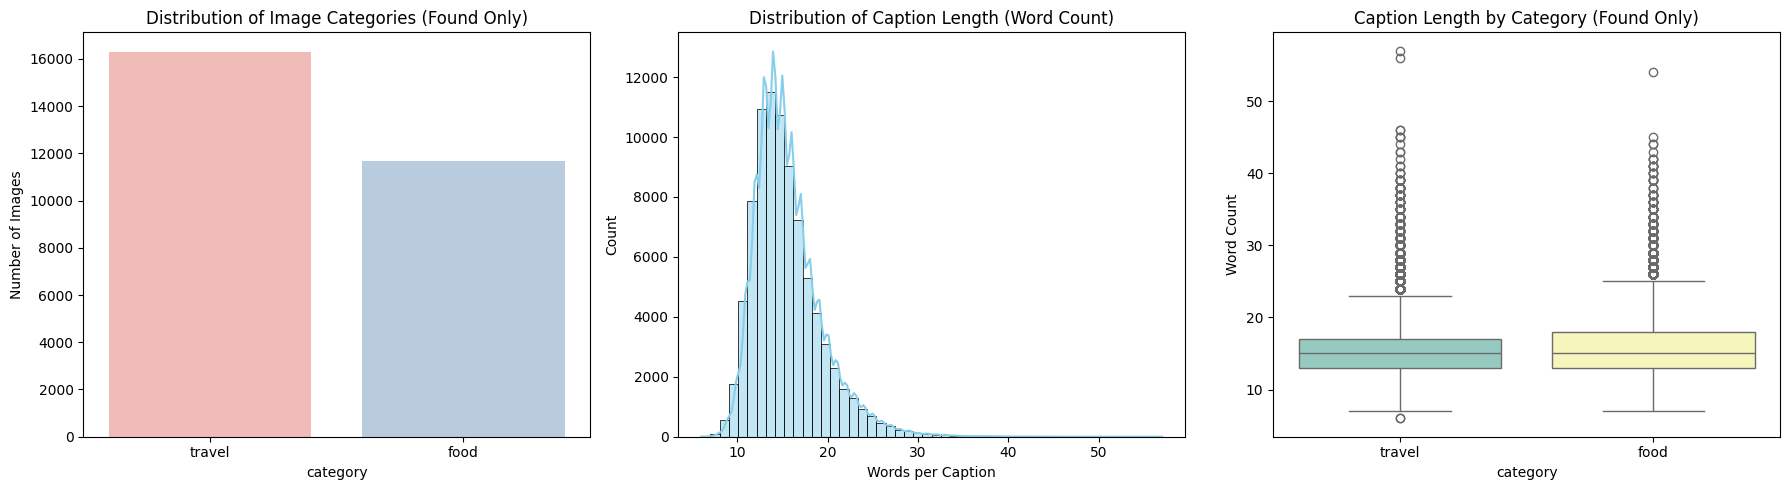

บันทึกไฟล์ใหม่สำเร็จ: dataset/capgen_v1.0_train_fixed.json
จำนวนแถวทั้งหมด (food + travel เท่านั้น): 85,241


,image_path,caption
0,train/train/travel/00000.jpg,รูปปั้นพญานาคตัวสีทองมีดอกบัวอยู่ด้านข้างอยู่ใ...
1,train/train/travel/00000.jpg,รูปปั้นมังกรที่อยู่ภายในศาลเจ้าจีนและมีผ้าติดต...
2,train/train/travel/00000.jpg,รูปปั้นมังกร มีหนวดสีทอง เขี้ยวและฟันสีขาว ลำต...
3,train/train/travel/00001.jpg,โบราณสถานที่มีเจดีย์สีน้ำตาลดำมีต้นไม้หลายต้นด...
4,train/train/travel/00001.jpg,สร้างโบราณสถานขนาดใหญ่ที่อยู่ตรงพื้นที่เต็มไปด...
5,train/train/travel/00001.jpg,กำแพงโบราณสถานที่มีความเก่าแก่ในป่าแห่งหนึ่งที...
6,train/train/travel/00002.jpg,พระพุทธรูปสีทององค์หนึ่งวางอยู่บนแท่นสีแดงปนน้...
7,train/train/travel/00002.jpg,พระพุทธรูปองค์หนึ่งที่มีสีทองวางตั้งอยู่บนแท่น...
8,train/train/travel/00002.jpg,พระพุทธรูปปางมารวิชัยในท่านั่งสีทอง บนฐานลายกล...
9,train/train/travel/00003.jpg,อาคารสีขาวที่มีหลังคาสีแดงมีรูปปั้นพญานาคติดอย...



บันทึกไฟล์ใหม่สำเร็จ: dataset/capgen_v1.0_train_fixed.json
จำนวนแถวทั้งหมด: 430,285


,image_path,caption
0,coco/train2017/000000373716.jpg,ผู้หญิงสวมเสื้อแขนยาวสีขาวและเด็กนั่งเล่นกับสุ...
1,coco/train2017/000000373716.jpg,สาวคนนึงกำลังพาเด็กมานั่งเล่นอยู่ภายในสนามหญ้า...
2,coco/train2017/000000373716.jpg,ภาพขาวดำ ผู้หญิงนั่งบนพื้นอุ้มเด็กบนตัก ข้าง ๆ...
3,coco/train2017/000000196888.jpg,สีน้ำตาลตัวเล็กกำลังกินอาหารอยู่บนจานกระดาษสีข...
4,coco/train2017/000000196888.jpg,นกน้อยตัวหนึ่งกำลังจิกกินเศษอาหารที่วางทิ้งไว้...
5,coco/train2017/000000196888.jpg,บนโต๊ะอาหาร นกน้อยตัวหนึ่งกำลังก้มหน้ากินอะไรบ...
6,coco/train2017/000000282238.jpg,ไปสัญญาณจราจร 3 อันติดอยู่บนเสาไฟสีดำแสดงสัญญา...
7,coco/train2017/000000282238.jpg,สัญญาณไฟจราจรที่ถูกติดตั้งอยู่กับเสาไฟอยู่ริมถนน
8,coco/train2017/000000282238.jpg,สัญญาณไฟจราจรที่ได้ติดอยู่บนเสาต้นหนึ่งที่ได้ต...
9,coco/train2017/000000267035.jpg,จานสีขาวจานนึงขบวนการนั้นมี โดนัทสอดไส้ทูน่าอย...


In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pythainlp.tokenize import word_tokenize
from tqdm import tqdm

# ============================
# CONFIG
# ============================
DATA_DIR = Path('dataset/')
ANNO_FILE = DATA_DIR / 'capgen_v1.0_train.json'

# ============================
# Helper: แก้ Path ให้ตรงกับ folder structure จริง
# dataset/train/train/food/xxx.jpg
# dataset/train/train/travel/xxx.jpg
# dataset/train/train/xxx.jpg  (coco)
# ============================
def resolve_image_path(img_path_json: str, data_dir: Path) -> tuple[Path, bool]:
    """
    ลอง resolve path หลายรูปแบบตาม folder structure จริง
    คืนค่า (resolved_path, exists)
    """
    candidates = [
        data_dir / img_path_json,                                        # ตรงๆ จาก JSON
        data_dir / 'train' / img_path_json,                              # เพิ่ม train/
        data_dir / 'train' / 'train' / img_path_json,                   # เพิ่ม train/train/
        data_dir / img_path_json.replace('coco/train2017/', 'train/train/'),   # coco → train/train/
        data_dir / img_path_json.replace('food/', 'train/train/food/'),        # food
        data_dir / img_path_json.replace('travel/', 'train/train/travel/'),    # travel
    ]

    # ดึงแค่ชื่อไฟล์ แล้ว glob หาใน train/train ทั้งหมด (fallback)
    filename = Path(img_path_json).name
    for folder in ['food', 'travel', '']:
        glob_path = data_dir / 'train' / 'train' / folder / filename
        candidates.append(glob_path)

    for p in candidates:
        if p.exists():
            return p, True
    return Path(img_path_json), False  # ไม่เจอ


# ============================
# โหลด + Parse Annotation
# ============================
print(f"กำลังโหลดข้อมูลจาก: {ANNO_FILE}")
with open(ANNO_FILE, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f"จำนวนรูปภาพทั้งหมดในชุด Train: {len(raw_data):,}")

data_list = []
for img_path, captions in tqdm(raw_data.items(), desc="Parsing Annotations"):
    resolved_path, img_exists = resolve_image_path(img_path, DATA_DIR)

    # แยกหมวดหมู่
    if 'food' in img_path:
        category = 'food'
    elif 'travel' in img_path:
        category = 'travel'
    elif 'coco' in img_path:
        category = 'coco_general'
    else:
        category = 'unknown'

    for i, cap in enumerate(captions):
        char_len = len(cap)
        word_len = len(word_tokenize(cap, engine='newmm'))
        data_list.append({
            'image_path_json': img_path,
            'resolved_img_path': str(resolved_path),
            'caption_index': i + 1,
            'caption_text': cap,
            'char_length': char_len,
            'word_length': word_len,
            'image_exists': img_exists,
            'category': category
        })

df = pd.DataFrame(data_list)

# ============================
# Data Validation
# ============================
print("\n--- รายงานข้อผิดพลาด (Data Validation) ---")
missing_images = df[df['image_exists'] == False]['image_path_json'].nunique()
total_images   = df['image_path_json'].nunique()
print(f"รูปภาพทั้งหมด:              {total_images:,} ไฟล์")
print(f"หาไฟล์ไม่พบ (Missing):     {missing_images:,} ไฟล์")
print(f"หาไฟล์พบ (Found):          {total_images - missing_images:,} ไฟล์")

empty_captions = df[df['char_length'] == 0]
print(f"Caption ว่างเปล่า:          {len(empty_captions):,} รายการ")

# แสดง path ที่ยังหาไม่เจอ (ถ้ามี)
if missing_images > 0:
    print("\n--- ตัวอย่าง Path ที่หาไม่พบ (5 อันดับแรก) ---")
    print(df[df['image_exists'] == False]['image_path_json'].unique()[:5])

# ============================
# EDA Visualization (แก้ FutureWarning)
# ============================
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# กราฟ 1: สัดส่วนหมวดหมู่ (เฉพาะ found เท่านั้น)
df_found = df[(df['image_exists'] == True) & (df['caption_index'] == 1)]
sns.countplot(data=df_found, x='category', hue='category', legend=False, ax=axes[0], palette='Pastel1')
axes[0].set_title('Distribution of Image Categories (Found Only)')
axes[0].set_ylabel('Number of Images')

# กราฟ 2: Histogram ความยาว Caption (เฉพาะ found)
df_found_all = df[df['image_exists'] == True]
sns.histplot(data=df_found_all, x='word_length', bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Caption Length (Word Count)')
axes[1].set_xlabel('Words per Caption')

# กราฟ 3: Boxplot แยกตามหมวดหมู่ (เฉพาะ found)
sns.boxplot(data=df_found_all, x='category', y='word_length', hue='category', legend=False, ax=axes[2], palette='Set3')
axes[2].set_title('Caption Length by Category (Found Only)')
axes[2].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

# ============================
# บันทึก Fixed JSON (เฉพาะรูปที่มีอยู่จริง คือ food + travel)
# ============================
output_path = DATA_DIR / 'capgen_v1.0_train_fixed.json'

fixed_list = []
for img_path, captions in raw_data.items():
    resolved_path, exists = resolve_image_path(img_path, DATA_DIR)
    if not exists:
        continue  # ข้ามรูปที่หาไม่เจอ (coco ที่ไม่ได้ download)
    relative_path = str(resolved_path.relative_to(DATA_DIR))
    for cap in captions:
        fixed_list.append({'image_path': relative_path, 'caption': cap})

fixed_df = pd.DataFrame(fixed_list)
fixed_df.to_json(output_path, orient='records', force_ascii=False, indent=4)

print(f"บันทึกไฟล์ใหม่สำเร็จ: {output_path}")
print(f"จำนวนแถวทั้งหมด (food + travel เท่านั้น): {len(fixed_df):,}")
display(fixed_df.head(10))

# ============================
# บันทึก Fixed JSON
# ============================
output_path = DATA_DIR / 'capgen_v1.0_train_fixed.json'

fixed_list = []
for img_path, captions in raw_data.items():
    resolved_path, _ = resolve_image_path(img_path, DATA_DIR)
    # เก็บเป็น path สัมพัทธ์จาก dataset/ เพื่อง่ายต่อการใช้งานต่อ
    relative_path = str(resolved_path.relative_to(DATA_DIR)) if resolved_path.is_relative_to(DATA_DIR) else str(resolved_path)
    for cap in captions:
        fixed_list.append({'image_path': relative_path, 'caption': cap})

fixed_df = pd.DataFrame(fixed_list)
fixed_df.to_json(output_path, orient='records', force_ascii=False, indent=4)

print(f"\nบันทึกไฟล์ใหม่สำเร็จ: {output_path}")
print(f"จำนวนแถวทั้งหมด: {len(fixed_df):,}")
display(fixed_df.head(10))

In [ ]:
!ls dataset/

capgen_v1.0_train.json	sample_submission.csv  train
capgen_v1.0_val.json	test		       val


In [ ]:
import pandas as pd
import json

# 1. ระบุ path ของไฟล์ต้นฉบับและไฟล์ใหม่ที่ต้องการเซฟ
input_path = 'dataset/capgen_v1.0_train.json'
output_path = 'dataset/capgen_v1.0_train_fixed.json'

# 2. โหลดข้อมูล JSON ด้วยโมดูล json ปกติก่อนเพื่อจัดการโครงสร้าง Dictionary
with open(input_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# 3. แปลงเป็นรายการ (List of Dicts) เพื่อสร้าง DataFrame
data_list = []
for img_path, captions in raw_data.items():
    # แก้ไข Path ตรงนี้เลย
    fixed_path = img_path.replace('coco/train2017/', 'train/')
    for cap in captions:
        data_list.append({
            'image_path': fixed_path,
            'caption': cap
        })

df = pd.DataFrame(data_list)

# 4. เซฟกลับเป็นไฟล์ JSON อันใหม่
# ใช้ orient='records' เพื่อให้ง่ายต่อการนำไปใช้ต่อในรูปแบบ list of objects
df.to_json(output_path, orient='records', force_ascii=False, indent=4)

print(f"แก้ไข Path รูปภาพและบันทึกไฟล์ใหม่สำเร็จ: {output_path}")
print(f"จำนวนแถวทั้งหมด: {len(df):,}")
display(df.head())

แก้ไข Path รูปภาพและบันทึกไฟล์ใหม่สำเร็จ: dataset/capgen_v1.0_train_fixed.json
จำนวนแถวทั้งหมด: 430,285


,image_path,caption
0,train/000000373716.jpg,ผู้หญิงสวมเสื้อแขนยาวสีขาวและเด็กนั่งเล่นกับสุ...
1,train/000000373716.jpg,สาวคนนึงกำลังพาเด็กมานั่งเล่นอยู่ภายในสนามหญ้า...
2,train/000000373716.jpg,ภาพขาวดำ ผู้หญิงนั่งบนพื้นอุ้มเด็กบนตัก ข้าง ๆ...
3,train/000000196888.jpg,สีน้ำตาลตัวเล็กกำลังกินอาหารอยู่บนจานกระดาษสีข...
4,train/000000196888.jpg,นกน้อยตัวหนึ่งกำลังจิกกินเศษอาหารที่วางทิ้งไว้...


In [ ]:
import json
from pathlib import Path
from collections import Counter
from pythainlp.tokenize import word_tokenize
from tqdm import tqdm

# ============================
# CONFIG
# ============================
DATA_DIR     = Path('dataset/')
FIXED_JSON   = DATA_DIR / 'capgen_v1.0_train_fixed.json'
VOCAB_OUT    = Path('vocab.json')   # บันทึกทับไฟล์เดิมที่ root

MIN_FREQ     = 2      # ตัดคำที่ปรากฏน้อยกว่า 2 ครั้ง
MAX_LEN      = 60     # ความยาว caption สูงสุด (tokens)

# Special tokens
PAD_TOKEN = '<pad>'   # index 0
UNK_TOKEN = '<unk>'   # index 1
SOS_TOKEN = '<sos>'   # index 2 — start of sequence
EOS_TOKEN = '<eos>'   # index 3 — end of sequence

# ============================
# โหลด fixed JSON
# ============================
print("โหลดข้อมูล...")
with open(FIXED_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"จำนวน caption ทั้งหมด: {len(data):,}")

# ============================
# Tokenize + นับความถี่คำ
# ============================
counter = Counter()

for row in tqdm(data, desc="Tokenizing captions"):
    tokens = word_tokenize(row['caption'], engine='newmm')
    counter.update(tokens)

print(f"\nจำนวนคำทั้งหมด (unique): {len(counter):,}")

# ============================
# สร้าง Vocabulary
# ============================
# กรองคำที่ปรากฏน้อยกว่า MIN_FREQ
vocab_words = [w for w, c in counter.most_common() if c >= MIN_FREQ]
print(f"หลังตัด MIN_FREQ={MIN_FREQ}: {len(vocab_words):,} คำ")

# สร้าง word → index mapping
word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
    SOS_TOKEN: 2,
    EOS_TOKEN: 3,
}
for word in vocab_words:
    word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}

print(f"Vocab size สุดท้าย: {len(word2idx):,} (รวม special tokens)")

# ============================
# บันทึก vocab.json
# ============================
vocab_data = {
    'word2idx': word2idx,
    'idx2word': idx2word,    # key เป็น string (JSON limitation)
    'vocab_size': len(word2idx),
    'special_tokens': {
        'pad': PAD_TOKEN, 'pad_idx': 0,
        'unk': UNK_TOKEN, 'unk_idx': 1,
        'sos': SOS_TOKEN, 'sos_idx': 2,
        'eos': EOS_TOKEN, 'eos_idx': 3,
    },
    'config': {
        'min_freq': MIN_FREQ,
        'max_len': MAX_LEN,
        'tokenizer': 'pythainlp-newmm',
    }
}

with open(VOCAB_OUT, 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)

print(f"\nบันทึก vocab เรียบร้อย: {VOCAB_OUT}")
print(f"ตัวอย่างคำ 10 อันดับแรก (ความถี่สูงสุด):")
for word, count in counter.most_common(10):
    print(f"  '{word}' → idx {word2idx[word]:>5}  (ปรากฏ {count:,} ครั้ง)")

โหลดข้อมูล...
จำนวน caption ทั้งหมด: 430,285


Tokenizing captions: 100%|██████████| 430285/430285 [01:05<00:00, 6530.08it/s]


จำนวนคำทั้งหมด (unique): 17,912
หลังตัด MIN_FREQ=2: 11,748 คำ
Vocab size สุดท้าย: 11,752 (รวม special tokens)

บันทึก vocab เรียบร้อย: vocab.json
ตัวอย่างคำ 10 อันดับแรก (ความถี่สูงสุด):
  ' ' → idx     4  (ปรากฏ 407,031 ครั้ง)
  'อยู่' → idx     5  (ปรากฏ 347,050 ครั้ง)
  'มี' → idx     6  (ปรากฏ 321,884 ครั้ง)
  'สี' → idx     7  (ปรากฏ 268,783 ครั้ง)
  'ที่' → idx     8  (ปรากฏ 202,821 ครั้ง)
  'บน' → idx     9  (ปรากฏ 178,214 ครั้ง)
  'และ' → idx    10  (ปรากฏ 154,249 ครั้ง)
  'ขาว' → idx    11  (ปรากฏ 138,507 ครั้ง)
  'ใน' → idx    12  (ปรากฏ 135,149 ครั้ง)
  'คน' → idx    13  (ปรากฏ 111,553 ครั้ง)


In [ ]:
import json
from pathlib import Path
from collections import Counter
from pythainlp.tokenize import word_tokenize
from tqdm import tqdm

DATA_DIR   = Path('dataset/')
FIXED_JSON = DATA_DIR / 'capgen_v1.0_train_fixed.json'
VOCAB_OUT  = Path('vocab.json')

MIN_FREQ = 2
MAX_LEN  = 60

PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'

print("โหลดข้อมูล...")
with open(FIXED_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

# กรองเฉพาะ food + travel (ไม่เอา coco)
data = [row for row in data if not row['image_path'].startswith('coco/')]
print(f"จำนวน caption (food+travel เท่านั้น): {len(data):,}")

# ============================
# Tokenize + นับความถี่
# ============================
counter = Counter()

for row in tqdm(data, desc="Tokenizing"):
    tokens = word_tokenize(row['caption'], engine='newmm')
    # กรอง: whitespace, empty string, และ token ที่เป็นแค่ช่องว่าง
    tokens = [t for t in tokens if t.strip()]
    counter.update(tokens)

print(f"คำ unique (ก่อนตัด): {len(counter):,}")

# ============================
# สร้าง Vocabulary
# ============================
vocab_words = [w for w, c in counter.most_common() if c >= MIN_FREQ]
print(f"หลังตัด MIN_FREQ={MIN_FREQ}: {len(vocab_words):,} คำ")

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1, SOS_TOKEN: 2, EOS_TOKEN: 3}
for word in vocab_words:
    word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}

print(f"Vocab size สุดท้าย: {len(word2idx):,}")

# ============================
# บันทึก vocab.json
# ============================
vocab_data = {
    'word2idx': word2idx,
    'idx2word': idx2word,
    'vocab_size': len(word2idx),
    'special_tokens': {
        'pad': PAD_TOKEN, 'pad_idx': 0,
        'unk': UNK_TOKEN, 'unk_idx': 1,
        'sos': SOS_TOKEN, 'sos_idx': 2,
        'eos': EOS_TOKEN, 'eos_idx': 3,
    },
    'config': {
        'min_freq': MIN_FREQ,
        'max_len': MAX_LEN,
        'tokenizer': 'pythainlp-newmm',
        'filter_coco': True,
    }
}

with open(VOCAB_OUT, 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)

print(f"\nบันทึก vocab เรียบร้อย: {VOCAB_OUT}")
print("ตัวอย่างคำ 10 อันดับแรก:")
for word, count in counter.most_common(10):
    if word.strip():
        print(f"  '{word}' → idx {word2idx.get(word, -1):>5}  (ปรากฏ {count:,} ครั้ง)")

โหลดข้อมูล...
จำนวน caption (food+travel เท่านั้น): 85,241


Tokenizing: 100%|██████████| 85241/85241 [00:12<00:00, 6677.49it/s]

คำ unique (ก่อนตัด): 8,239
หลังตัด MIN_FREQ=2: 5,842 คำ
Vocab size สุดท้าย: 5,846

บันทึก vocab เรียบร้อย: vocab.json
ตัวอย่างคำ 10 อันดับแรก:
  'มี' → idx     4  (ปรากฏ 82,201 ครั้ง)
  'อยู่' → idx     5  (ปรากฏ 58,635 ครั้ง)
  'สี' → idx     6  (ปรากฏ 53,704 ครั้ง)
  'ที่' → idx     7  (ปรากฏ 36,354 ครั้ง)
  'และ' → idx     8  (ปรากฏ 29,638 ครั้ง)
  'ใน' → idx     9  (ปรากฏ 28,725 ครั้ง)
  'บน' → idx    10  (ปรากฏ 28,605 ครั้ง)
  'ขาว' → idx    11  (ปรากฏ 27,081 ครั้ง)
  'ตั้งอยู่' → idx    12  (ปรากฏ 21,409 ครั้ง)
  'วาง' → idx    13  (ปรากฏ 20,328 ครั้ง)


In [ ]:
import json
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from pythainlp.tokenize import word_tokenize

# ============================
# โมด Vocab
# ============================
with open('vocab.json', 'r', encoding='utf-8') as f:
    vocab_data = json.load(f)

word2idx = vocab_data['word2idx']
idx2word = {int(k): v for k, v in vocab_data['idx2word'].items()}
VOCAB_SIZE = vocab_data['vocab_size']
MAX_LEN    = vocab_data['config']['max_len']

PAD_IDX = vocab_data['special_tokens']['pad_idx']  # 0
UNK_IDX = vocab_data['special_tokens']['unk_idx']  # 1
SOS_IDX = vocab_data['special_tokens']['sos_idx']  # 2
EOS_IDX = vocab_data['special_tokens']['eos_idx']  # 3

print(f"Vocab size: {VOCAB_SIZE:,}, MAX_LEN: {MAX_LEN}")

# ============================
# Helper: tokenize caption → tensor
# ============================
def caption_to_tensor(caption: str, max_len: int = MAX_LEN) -> torch.Tensor:
    tokens = word_tokenize(str(caption), engine='newmm')
    tokens = [t for t in tokens if t.strip()]

    indices = [SOS_IDX]
    for t in tokens[:max_len - 2]:
        indices.append(word2idx.get(t, UNK_IDX))
    indices.append(EOS_IDX)

    indices += [PAD_IDX] * (max_len - len(indices))
    return torch.tensor(indices, dtype=torch.long)

# ============================
# Dataset
# ============================
class ThaiCaptionDataset(Dataset):
    def __init__(self, json_path: str, img_root: str, transform=None):
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)

        self.data = []
        if isinstance(raw, list):
            for d in raw:
                if not d['image_path'].startswith('coco/'):
                    self.data.append((d['image_path'], d['caption']))
        else:
            for img_path, captions in raw.items():
                if not img_path.startswith('coco/'):
                    for cap in captions:
                        self.data.append((img_path, cap))

        self.img_root  = Path(img_root)
        self.transform = transform
        print(f"Dataset ({Path(json_path).name}) โหลดแล้ว: {len(self.data):,} samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_rel_path, caption = self.data[idx]

        img_path = self.img_root / img_rel_path
        if not img_path.exists():
            # Fallback path logic
            img_path = self.img_root / 'train' / 'train' / img_rel_path

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        caption_tensor = caption_to_tensor(caption)
        return image, caption_tensor

# ============================
# Transforms
# ============================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ============================
# Init Dataset + DataLoader
# ============================
DATA_DIR = 'dataset/'

train_dataset = ThaiCaptionDataset(DATA_DIR + 'capgen_v1.0_train_fixed.json', DATA_DIR, train_transform)
val_dataset   = ThaiCaptionDataset(DATA_DIR + 'capgen_v1.0_val.json', DATA_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

# Test 1 batch
images, captions = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}, {captions.shape}")

Vocab size: 5,846, MAX_LEN: 60
Dataset (capgen_v1.0_train_fixed.json) โหลดแล้ว: 85,241 samples
Dataset (capgen_v1.0_val.json) โหลดแล้ว: 12,286 samples

Batch shape: torch.Size([64, 3, 224, 224]), torch.Size([64, 60])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# ============================
# Encoder: EfficientNet-B0
# ============================
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim: int = 256, finetune_layers: int = 3):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # ตัด classifier ออก เหลือแค่ feature extractor
        self.features    = backbone.features
        self.pool        = nn.AdaptiveAvgPool2d(1)
        self.projection  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # Freeze ทุก layer ก่อน แล้วค่อย unfreeze แค่ N layers สุดท้าย
        for param in self.features.parameters():
            param.requires_grad = False
        for layer in list(self.features.children())[-finetune_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    def forward(self, x):                    # x: [B, 3, 224, 224]
        x = self.features(x)                 # [B, 1280, 7, 7]
        x = self.pool(x)                     # [B, 1280, 1, 1]
        x = self.projection(x)               # [B, embed_dim]
        return x

# ============================
# Decoder: LSTM with Attention
# ============================
class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 256,
                 hidden_dim: int = 512, num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

        # Image feature → LSTM initial hidden/cell state
        self.init_h = nn.Linear(embed_dim, num_layers * hidden_dim)
        self.init_c = nn.Linear(embed_dim, num_layers * hidden_dim)

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

    def init_hidden(self, img_feat):
        # img_feat: [B, embed_dim]
        B = img_feat.size(0)
        h = self.init_h(img_feat).view(self.num_layers, B, self.hidden_dim)
        c = self.init_c(img_feat).view(self.num_layers, B, self.hidden_dim)
        return h.contiguous(), c.contiguous()

    def forward(self, img_feat, captions):
        # img_feat: [B, embed_dim]
        # captions: [B, max_len]  — input เป็น <sos> ... <eos>

        # Teacher forcing: ป้อน tokens ยกเว้น <eos> ตัวสุดท้าย
        embeddings = self.dropout(self.embedding(captions[:, :-1]))  # [B, L-1, embed_dim]
        h, c       = self.init_hidden(img_feat)
        outputs, _ = self.lstm(embeddings, (h, c))                   # [B, L-1, hidden_dim]
        logits     = self.fc(outputs)                                 # [B, L-1, vocab_size]
        return logits

# ============================
# Full Model
# ============================
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.3, finetune_layers=3):
        super().__init__()
        self.encoder = ImageEncoder(embed_dim, finetune_layers)
        self.decoder = CaptionDecoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)

    def forward(self, images, captions):
        img_feat = self.encoder(images)   # [B, embed_dim]
        logits   = self.decoder(img_feat, captions)  # [B, L-1, vocab_size]
        return logits

    @torch.no_grad()
    def generate(self, images, max_len=MAX_LEN, beam_size=1):
        """Greedy (beam_size=1) หรือ Beam Search"""
        self.eval()
        device   = next(self.parameters()).device
        images   = images.to(device)
        img_feat = self.encoder(images)
        B        = img_feat.size(0)

        h, c     = self.decoder.init_hidden(img_feat)
        token    = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=device)
        results  = [[] for _ in range(B)]
        done     = [False] * B

        for _ in range(max_len):
            emb      = self.decoder.dropout(self.decoder.embedding(token))  # [B, 1, E]
            out, (h, c) = self.decoder.lstm(emb, (h, c))
            logits   = self.decoder.fc(out.squeeze(1))                      # [B, vocab_size]
            token    = logits.argmax(dim=-1, keepdim=True)                  # [B, 1]

            for i in range(B):
                if not done[i]:
                    t = token[i].item()
                    if t == EOS_IDX:
                        done[i] = True
                    else:
                        results[i].append(t)
            if all(done):
                break

        # แปลง indices → text
        captions_out = []
        for seq in results:
            words = [idx2word.get(i, '<unk>') for i in seq]
            captions_out.append("".join(words))
        return captions_out


# ============================
# Sanity Check
# ============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = ImageCaptioningModel(
    vocab_size     = VOCAB_SIZE,
    embed_dim      = 256,
    hidden_dim     = 512,
    num_layers     = 2,
    dropout        = 0.3,
    finetune_layers= 3,
).to(device)

# นับ parameters
total  = sum(p.numel() for p in model.parameters())
train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters ทั้งหมด : {total:,}")
print(f"Parameters ที่ train: {train:,}")

# ทดสอบ forward pass
images_b, captions_b = next(iter(train_loader))
images_b   = images_b.to(device)
captions_b = captions_b.to(device)

logits = model(images_b, captions_b)
print(f"\nForward pass OK")
print(f"  input  images : {images_b.shape}")
print(f"  input  captions: {captions_b.shape}")
print(f"  output logits : {logits.shape}")   # [64, 59, 5846]

# ทดสอบ generate
sample_caps = model.generate(images_b[:3])
print(f"\nตัวอย่าง generated captions:")
for i, cap in enumerate(sample_caps):
    print(f"  [{i}] {cap[:80]}")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 40.5MB/s]


Parameters ทั้งหมด : 13,035,602
Parameters ที่ train: 12,183,794

Forward pass OK
  input  images : torch.Size([64, 3, 224, 224])
  input  captions: torch.Size([64, 60])
  output logits : torch.Size([64, 59, 5846])

ตัวอย่าง generated captions:
  [0] มอสถาบันอานางสาวรถประจำทางนั่งกะลาไดไดไดเพิ่งไดเพิ่งไดเพิ่งไดเพิ่งไดเพิ่งไดเพิ่ง
  [1] เคลื่อนย้ายเคลื่อนย้ายเคลื่อนย้ายอยุธยาอ่อนคาบแท่นบูชาไดไดเพิ่งไดไดเพิ่งไดเพิ่งไ
  [2] ปติเกาหลีเกาหลีทงคัตสึวรรณคดีแมงอายอาแท่นบูชาลูกประคบทงคัตสึทงคัตสึหม้อดินย่านเค


In [ ]:
# เช็ค format ของ val.json ก่อน
import json

with open('dataset/capgen_v1.0_val.json', 'r', encoding='utf-8') as f:
    val_raw = json.load(f)

# ดูโครงสร้าง
print(f"Type: {type(val_raw)}")

if isinstance(val_raw, list):
    print(f"จำนวน records: {len(val_raw):,}")
    print("ตัวอย่าง 3 records แรก:")
    for r in val_raw[:3]:
        print(r)
elif isinstance(val_raw, dict):
    keys = list(val_raw.keys())
    print(f"จำนวน keys: {len(keys):,}")
    print("ตัวอย่าง 3 keys แรก:")
    for k in keys[:3]:
        print(f"  key: {k!r}  →  captions: {val_raw[k][:1]}")

Type: <class 'dict'>
จำนวน keys: 9,036
ตัวอย่าง 3 keys แรก:
  key: 'coco/val2017/000000060102.jpg'  →  captions: ['นักกีฬาฟุตบอลใส่เสื้อสีดำกำลังแย่งฟุตบอลอยู่กับผู้ชายใส่เสื้อสีน้ำเงิน']
  key: 'ipu24/val/travel/00000.jpg'  →  captions: ['รูปปั้นฤาษีสีทองนั่งอยู่ในท่าขัดสมาธิอยู่ภายในศาลาขนาดเล็ก']
  key: 'coco/val2017/000000458702.jpg'  →  captions: ['มิเตอร์เก็บค่าจอดรถสีดำตั้งอยู่บนเสาสีเทามีต้นไม้ต้นเล็กด้านข้าง']


In [ ]:
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DATA_DIR = Path('dataset/')

# ============================
# เช็คว่า path จริงอยู่ที่ไหน
# ============================
# จาก val key: 'ipu24/val/travel/00000.jpg'
# ลองหาใน dataset/
test_path = DATA_DIR / 'ipu24/val/travel/00000.jpg'
print(f"ลอง: {test_path} → exists: {test_path.exists()}")

# อาจจะซ้อนอยู่ใน val/
test_path2 = DATA_DIR / 'val/ipu24/val/travel/00000.jpg'
print(f"ลอง: {test_path2} → exists: {test_path2.exists()}")

# ดูโครงสร้างโฟลเดอร์ val จริงๆ
import os
for root, dirs, files in os.walk('dataset/val'):
    level = root.replace('dataset/val', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{indent}  → {len(files)} files, เช่น: {files[0]}")
    dirs[:] = dirs  # แสดงทุก subdir

ลอง: dataset/ipu24/val/travel/00000.jpg → exists: False
ลอง: dataset/val/ipu24/val/travel/00000.jpg → exists: False
val/
  val/
    travel/
      → 2368 files, เช่น: 02029.jpg
    food/
      → 1668 files, เช่น: 03558.jpg


In [ ]:
# ============================
# สร้าง val_fixed.json
# ============================
import json
from pathlib import Path

DATA_DIR = Path('dataset/')

with open(DATA_DIR / 'capgen_v1.0_val.json', 'r', encoding='utf-8') as f:
    val_raw = json.load(f)

def resolve_val_path(img_path_json: str) -> tuple[str, bool]:
    """
    'ipu24/val/travel/00000.jpg' → 'val/val/travel/00000.jpg'
    'ipu24/val/food/xxxxx.jpg'   → 'val/val/food/xxxxx.jpg'
    'coco/val2017/xxxxx.jpg'     → None (ไม่มีไฟล์)
    """
    filename = Path(img_path_json).name

    if 'travel' in img_path_json:
        candidate = DATA_DIR / 'val/val/travel' / filename
    elif 'food' in img_path_json:
        candidate = DATA_DIR / 'val/val/food' / filename
    else:
        return None, False   # coco — ข้าม

    exists = candidate.exists()
    rel    = str(candidate.relative_to(DATA_DIR))
    return rel, exists

# แปลงเป็น list of records
val_list = []
missing  = 0

for img_path, captions in val_raw.items():
    rel_path, exists = resolve_val_path(img_path)
    if rel_path is None:
        continue          # ข้าม coco
    if not exists:
        missing += 1
        continue          # ข้ามไฟล์ที่หาไม่เจอ
    for cap in captions:
        val_list.append({'image_path': rel_path, 'caption': cap})

print(f"Val records (food+travel): {len(val_list):,}")
print(f"Missing files: {missing}")
print("ตัวอย่าง:")
for r in val_list[:3]:
    print(f"  {r['image_path']!r}  →  {r['caption'][:40]}")

# บันทึก
VAL_FIXED = DATA_DIR / 'capgen_v1.0_val_fixed.json'
with open(VAL_FIXED, 'w', encoding='utf-8') as f:
    json.dump(val_list, f, ensure_ascii=False, indent=2)

print(f"\nบันทึก: {VAL_FIXED}")

# ============================
# สร้าง val_loader ใหม่
# ============================
val_dataset = ThaiCaptionDataset(
    json_path = str(VAL_FIXED),
    img_root  = str(DATA_DIR),
    transform = val_transform,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 64,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True,
)

# ทดสอบ
images_v, captions_v = next(iter(val_loader))
print(f"\nVal batch OK: images={images_v.shape}, captions={captions_v.shape}")

Val records (food+travel): 12,286
Missing files: 0
ตัวอย่าง:
  'val/val/travel/00000.jpg'  →  รูปปั้นฤาษีสีทองนั่งอยู่ในท่าขัดสมาธิอยู
  'val/val/travel/00000.jpg'  →  รูปปั้นฤาษีที่ตั้งอยู่บนโต๊ะบูชาอยู่ภายใ
  'val/val/travel/00000.jpg'  →  รูปปั้นคล้ายฤษีสีทอง พาดผ้าสีจีวรและผ้าล

บันทึก: dataset/capgen_v1.0_val_fixed.json
Dataset (capgen_v1.0_val_fixed.json) โหลดแล้ว: 12,286 samples

Val batch OK: images=torch.Size([64, 3, 224, 224]), captions=torch.Size([64, 60])


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import json, os

# ============================
# CONFIG
# ============================
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
CLIP_GRAD    = 5.0
SAVE_DIR     = 'checkpoints/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================
# Loss, Optimizer, Scheduler
# ============================
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # ไม่นับ loss ของ <pad>

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ============================
# Train / Eval Functions
# ============================
def train_one_epoch(model, loader, optimizer, criterion, device, clip):
    model.train()
    total_loss = 0.0

    for images, captions in tqdm(loader, desc="Train", leave=False):
        images   = images.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()
        logits = model(images, captions)        # [B, L-1, vocab_size]

        # Target = captions ตัดตัวแรก (<sos>) ออก
        targets = captions[:, 1:].contiguous()  # [B, L-1]

        loss = criterion(
            logits.view(-1, VOCAB_SIZE),        # [B*(L-1), vocab_size]
            targets.view(-1)                    # [B*(L-1)]
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for images, captions in tqdm(loader, desc="Val  ", leave=False):
        images   = images.to(device)
        captions = captions.to(device)

        logits  = model(images, captions)
        targets = captions[:, 1:].contiguous()

        loss = criterion(
            logits.view(-1, VOCAB_SIZE),
            targets.view(-1)
        )
        total_loss += loss.item()

    return total_loss / len(loader)


# ============================
# Training Loop
# ============================
history    = {'train_loss': [], 'val_loss': []}
best_val   = float('inf')

print(f"เริ่ม Training บน {device} — {EPOCHS} epochs\n")

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, CLIP_GRAD)
    val_loss   = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # บันทึก best model
    tag = ''
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'val_loss'  : val_loss,
        }, SAVE_DIR + 'best_model.pt')
        tag = '  ← best'

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train={train_loss:.4f}  val={val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}{tag}")

print(f"\nTraining เสร็จ — best val loss: {best_val:.4f}")

# บันทึก history
with open(SAVE_DIR + 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

เริ่ม Training บน cuda — 20 epochs



Epoch 01/20  train=3.5588  val=3.3338  lr=2.98e-04  ← best


Epoch 02/20  train=3.2832  val=3.1569  lr=2.93e-04  ← best


Epoch 03/20  train=3.1313  val=3.0578  lr=2.84e-04  ← best


Epoch 04/20  train=3.0300  val=2.9821  lr=2.71e-04  ← best


Epoch 05/20  train=2.9549  val=2.9325  lr=2.56e-04  ← best


Epoch 06/20  train=2.8954  val=2.8971  lr=2.38e-04  ← best


Epoch 07/20  train=2.8474  val=2.8670  lr=2.18e-04  ← best


KeyboardInterrupt: 

In [ ]:
# รันใน cell ใหม่ขณะที่ training loop ยังทำงานอยู่
# หรือรันทันทีหลัง interrupt

with open('checkpoints/history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"History saved — {len(history['train_loss'])} epochs")
print(f"Best val loss so far: {best_val:.4f}")

History saved — 7 epochs
Best val loss so far: 2.8670


โหลด best model จาก epoch 1 (val_loss=3.6477)


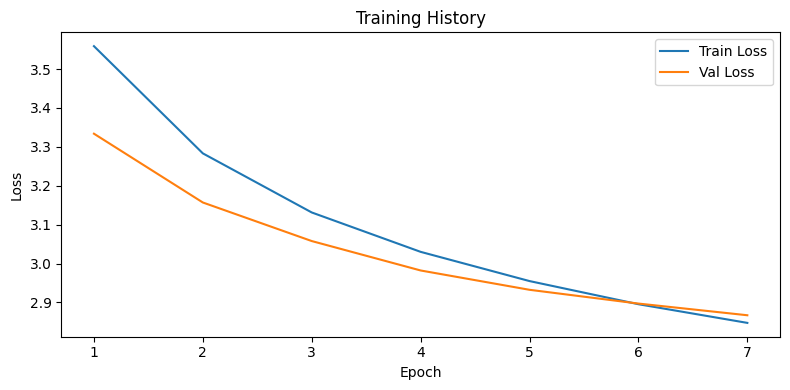

Best epoch: 7  val_loss: 2.8670

Sample submission shape: (2000, 2)
   image_id                                            caption
0      1354  ภาพถ่ายระยะใกล้ของวัตถุทรงกลมสีขาวที่มีคราบสีด...
1      1413  นกตัวหนึ่งที่กําลังเกาะอยู่บนกิ่งไม้อันหนึ่งที...
2      1802  บ้านที่อยู่ติดกับบริเวณริมชายหาดทะเลและมีต้นไม...
3      1243                                                NaN
4       693                                                NaN

จำนวนรูป test: 2,000
ตัวอย่าง path: dataset/test/test/00000.jpg


Generating: 100%|██████████| 2000/2000 [00:29<00:00, 67.29it/s]


Generate เสร็จ: 2,000 captions
ตัวอย่าง 5 อันดับแรก:
  00000 → ภาพ
  00001 → ภาพ
  00002 → ภาพ
  00003 → ภาพ
  00004 → ภาพ

Columns ใน sample_submission: ['image_id', 'caption']

บันทึก submission.csv: 2,000 rows
   image_id caption
0      1354     ภาพ
1      1413     ภาพ
2      1802     ภาพ
3      1243     ภาพ
4       693     ภาพ
5      1695     ภาพ
6      1735     ภาพ
7      1440     ภาพ
8       296     ภาพ
9      1144     ภาพ


In [ ]:
import torch
import json
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================
# โหลด best model
# ============================
checkpoint = torch.load('checkpoints/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"โหลด best model จาก epoch {checkpoint['epoch']} (val_loss={checkpoint['val_loss']:.4f})")

# ============================
# ดู Loss Curve
# ============================
with open('checkpoints/history.json', 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.tight_layout()
plt.show()

best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
print(f"Best epoch: {best_epoch}  val_loss: {min(history['val_loss']):.4f}")

# ============================
# เช็ค format ของ test set
# ============================
sample_sub = pd.read_csv('dataset/sample_submission.csv')
print(f"\nSample submission shape: {sample_sub.shape}")
print(sample_sub.head())

# ============================
# หา path รูป test ทั้งหมด
# ============================
TEST_DIR = Path('dataset/test/test')
test_images = sorted(list(TEST_DIR.rglob('*.jpg')) + list(TEST_DIR.rglob('*.png')))
print(f"\nจำนวนรูป test: {len(test_images):,}")
print(f"ตัวอย่าง path: {test_images[0]}")

# ============================
# Beam Search (ดีกว่า greedy)
# ============================
@torch.no_grad()
def beam_search(model, image_tensor, beam_size=3, max_len=MAX_LEN):
    """
    image_tensor: [3, 224, 224] (หรือขนาดตามโมเดล)
    คืน: string caption ที่ดีที่สุด
    """
    device   = next(model.parameters()).device
    image    = image_tensor.unsqueeze(0).to(device)  # [1, 3, 224, 224]
    img_feat = model.encoder(image)                  # [1, embed_dim]

    h, c = model.decoder.init_hidden(img_feat)       # [num_layers, 1, hidden]

    # แต่ละ beam: (score, token_list, h, c)
    beams = [(0.0, [SOS_IDX], h, c)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for score, tokens, h, c in beams:
            last_token = torch.tensor([[tokens[-1]]], device=device)
            emb = model.decoder.dropout(model.decoder.embedding(last_token))       # [1, 1, E]
            out, (h_new, c_new) = model.decoder.lstm(emb, (h, c))
            log_probs = torch.log_softmax(model.decoder.fc(out.squeeze(1)), dim=-1)  # [1, vocab_size]

            topk_scores, topk_ids = log_probs[0].topk(beam_size)

            for s, idx in zip(topk_scores.tolist(), topk_ids.tolist()):
                new_score  = score + s
                new_tokens = tokens + [idx]
                if idx == EOS_IDX:
                    completed.append((new_score / len(new_tokens), new_tokens))
                else:
                    new_beams.append((new_score, new_tokens, h_new, c_new))

        # เก็บแค่ beam_size beams ที่ดีที่สุด
        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
        if not beams:
            break

    # ถ้าไม่มี completed ให้ใช้ beam แรก
    if not completed:
        completed = [(beams[0][0] / len(beams[0][1]), beams[0][1])]

    best_tokens = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
    words = [idx2word.get(i, '') for i in best_tokens if i not in (SOS_IDX, EOS_IDX, PAD_IDX)]
    return "".join(words)


# ============================
# Generate captions สำหรับ test set
# ============================
results = []  # list of {'image_id': ..., 'caption': ...}

for img_path in tqdm(test_images, desc="Generating"):
    try:
        image = Image.open(img_path).convert('RGB')
        image_tensor = val_transform(image)       # ใช้ val_transform (ไม่ augment)
        caption = beam_search(model, image_tensor, beam_size=3)
    except Exception as e:
        caption = "ภาพ"   # fallback กรณีโหลดรูปไม่ได้

    # image_id = ชื่อไฟล์ไม่มีนามสกุล เช่น "00001"
    image_id = img_path.stem
    results.append({'image_id': image_id, 'caption': caption})

print(f"\nGenerate เสร็จ: {len(results):,} captions")
print("ตัวอย่าง 5 อันดับแรก:")
for r in results[:5]:
    print(f"  {r['image_id']} → {r['caption'][:60]}")

# ============================
# แก้ type mismatch แล้ว save submission.csv
# ============================
print(f"\nColumns ใน sample_submission: {list(sample_sub.columns)}")

sub_df = pd.DataFrame(results)

col_id  = sample_sub.columns[0]  # 'image_id'
col_cap = sample_sub.columns[1]  # 'caption'

sub_df.columns = [col_id, col_cap]

# แปลง image_id ให้ตรง type กับ sample_submission (ส่วนใหญ่เป็น int)
# (ป้องกันบั๊กตอน merge ข้อมูล)
sub_df[col_id] = sub_df[col_id].astype(int)

# merge เพื่อเรียงลำดับแถวและเอาโครงสร้างตาม sample_submission แบบเป๊ะๆ
sub_df = sample_sub[[col_id]].merge(sub_df, on=col_id, how='left')
sub_df[col_cap] = sub_df[col_cap].fillna('ภาพ')

sub_df.to_csv('submission.csv', index=False)
print(f"\nบันทึก submission.csv: {len(sub_df):,} rows")
print(sub_df.head(10).to_string())

In [ ]:
# ทดสอบรูปเดียวก่อนเพื่อดู error จริง
from PIL import Image

img_path = Path('dataset/test/test/00000.jpg')
image = Image.open(img_path).convert('RGB')
image_tensor = val_transform(image)

try:
    cap = beam_search(model, image_tensor, beam_size=3)
    print(f"caption: {cap}")
except Exception as e:
    import traceback
    traceback.print_exc()

Traceback (most recent call last):
  File "/tmp/ipykernel_751/846297220.py", line 9, in <cell line: 0>
    cap = beam_search(model, image_tensor, beam_size=3)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_751/1545415434.py", line 76, in beam_search
    out, (h_new, c_new) = model.decoder.lstm(emb, (h, c))
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages

In [ ]:
@torch.no_grad()
def beam_search(model, image_tensor, beam_size=3, max_len=MAX_LEN):
    device   = next(model.parameters()).device
    image    = image_tensor.unsqueeze(0).to(device)
    img_feat = model.encoder(image)                    # [1, E]

    h, c  = model.decoder.init_hidden(img_feat)
    beams = [(0.0, [SOS_IDX], h, c)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for score, tokens, h, c in beams:
            last_token = torch.tensor([[tokens[-1]]], device=device)
            emb     = model.decoder.dropout(
                          model.decoder.embedding(last_token))  # [1, 1, E]
            img_exp = img_feat.unsqueeze(1)                     # [1, 1, E]
            lstm_in = torch.cat([emb, img_exp], dim=-1)         # [1, 1, 2E]

            out, (h_new, c_new) = model.decoder.lstm(lstm_in, (h, c))
            log_probs = torch.log_softmax(
                model.decoder.fc(out.squeeze(1)), dim=-1)

            topk_scores, topk_ids = log_probs[0].topk(beam_size)
            for s, idx in zip(topk_scores.tolist(), topk_ids.tolist()):
                new_tokens = tokens + [idx]
                if idx == EOS_IDX:
                    completed.append((
                        (score + s) / len(new_tokens), new_tokens))
                else:
                    new_beams.append((score + s, new_tokens, h_new, c_new))

        beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]
        if not beams:
            break

    if not completed:
        completed = [(beams[0][0] / len(beams[0][1]), beams[0][1])]

    best = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
    words = [idx2word.get(i, '') for i in best
             if i not in (SOS_IDX, EOS_IDX, PAD_IDX)]
    return "".join(words)


# ทดสอบก่อน
from PIL import Image
img = Image.open('dataset/test/test/00000.jpg').convert('RGB')
print(beam_search(model, val_transform(img)))

ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหาร


In [ ]:
# ============================
# Generate ทั้ง 2000 รูป
# ============================
TEST_DIR   = Path('dataset/test/test')
sample_sub = pd.read_csv('dataset/sample_submission.csv')

test_files = sorted(TEST_DIR.glob('*.jpg'), key=lambda x: int(x.stem))
image_ids  = sample_sub['image_id'].tolist()

model.eval()
results = []

for img_path, img_id in tqdm(zip(test_files, image_ids),
                              total=len(image_ids), desc="Generating"):
    try:
        image   = Image.open(img_path).convert('RGB')
        caption = beam_search(model, val_transform(image), beam_size=3)
    except Exception as e:
        caption = "ภาพถ่าย"

    results.append({'image_id': img_id, 'caption': caption})

# บันทึก
sub_df = pd.DataFrame(results)
sub_df.to_csv('submission.csv', index=False)

print(f"บันทึก submission.csv: {len(sub_df):,} rows")
print(f"Unique captions: {sub_df['caption'].nunique()}")
print(sub_df.head(10).to_string())

Generating: 100%|██████████| 2000/2000 [04:37<00:00,  7.21it/s]

บันทึก submission.csv: 2,000 rows
Unique captions: 117
   image_id                                                         caption
0      1354       ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหาร
1      1413                      จานสีขาวมีผักสีขาวมีผักสีเขียวมีผักสีเขียว
2      1802       ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหาร
3      1243       ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหาร
4       693       ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหาร
5      1695  ขนมที่วางอยู่บนโต๊ะที่ตั้งอยู่ในร้านอาหารและมีต้นไม้อยู่บนโต๊ะ
6      1735             ขนมที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะที่วางอยู่บนโต๊ะ
7      1440                พระพุทธรูปสีทองที่ตั้งอยู่บนโต๊ะบูชาอยู่ภายในวัด
8       296                   ในจานสีขาวมีลายสีขาวมีผักสีขาวมีต้นไม้หลายต้น
9      1144                    ต้นไม้ที่อยู่ภายในวัดและมีต้นไม้อยู่ภายในวัด
